# 🎨 Seaborn — Statistical Data Visualization with Python

> **Step 2: Data Science**
>
> **Library 04: Seaborn**
>
> **Date: February 6, 2024** 🎯
>
> **Class 20 — Seaborn Fundamentals and Statistical Data Visualization**

---
# 🎯 Learning Objectives

By the end of this notebook you should be able to use Seaborn's relational, distribution, categorical, regression and matrix plots; use `hue`, `style`, `size`; build pair plots, joint plots, heatmaps and FacetGrids; combine Seaborn with Pandas and Matplotlib; and run a visual EDA workflow.

---
## 📌 What is Seaborn?

**Seaborn** is a Python data visualization library built on top of **Matplotlib**.

It makes it easier to create **beautiful, informative, and statistical visualizations** from structured datasets.

Seaborn is especially useful for:

* 📊 Data analysis
* 🔎 Exploratory Data Analysis (EDA)
* 📈 Statistical visualization
* 🤖 Machine Learning data exploration
* 🧹 Understanding relationships between variables
* 📉 Finding patterns, trends, and outliers

```text
Matplotlib → More control + low-level visualization
Seaborn    → Easier + statistical + better-looking visualizations
```

---
# 🎯 Why Learn Seaborn?

Matplotlib gives you complete control over a chart, but creating statistical plots can require more code. Seaborn provides convenient functions for common Data Science visualizations.

For example, `sns.scatterplot(data=df, x="age", y="salary")` can quickly show the relationship between **age and salary**.

---
# 📦 Installation

```bash
pip install seaborn
```

Import (common convention `sns`):

In [3]:
pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# pip install seaborn   (run once if needed)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline
print("Seaborn version:", sns.__version__)

Seaborn version: 0.13.2


---
# 🧠 Seaborn and Matplotlib

```text
Python Data → Pandas → Seaborn → Matplotlib → Visualization
```

Seaborn can create the plot, while Matplotlib can be used to customize it further.

---
# 🧩 Main Seaborn Concepts

```text
Seaborn
│
├── Introduction · Dataset Preparation · Themes and Styles · Color Palettes
├── Relational Plots   → scatterplot(), lineplot()
├── Distribution Plots → histplot(), kdeplot(), ecdfplot()
├── Categorical Plots  → barplot(), countplot(), boxplot(), violinplot(), stripplot(), swarmplot()
├── Regression Plots   → regplot(), lmplot()
├── Relationship Analysis → pairplot(), jointplot()
├── Matrix Plots       → heatmap(), clustermap()
├── Faceting           → FacetGrid
└── Figure and Axes · Matplotlib Integration · Pandas Integration · EDA · Mini Project
```

---
# 📊 1. Understanding the Dataset

Seaborn works especially well with **Pandas DataFrames**.

In [5]:
data = {
    "Name": ["Ali", "Ahmed", "Sara", "Ayesha"],
    "Age": [20, 22, 21, 23],
    "Marks": [75, 88, 92, 81]
}

df = pd.DataFrame(data)

print(df)

     Name  Age  Marks
0     Ali   20     75
1   Ahmed   22     88
2    Sara   21     92
3  Ayesha   23     81


Seaborn can directly use this DataFrame.

> 💡 The small table above is enough for basic plots. For the richer plots later (box, violin, heatmap, pair plot…) we generate a **larger employee/student dataset** so the charts have something to show.

In [6]:
# A larger, reproducible dataset used in the rest of the notebook
rng = np.random.default_rng(42)
n = 150

big = pd.DataFrame({
    "Name": [f"Person_{i}" for i in range(n)],
    "Gender": rng.choice(["Male", "Female"], n),
    "Department": rng.choice(["IT", "Marketing", "HR", "Finance"], n, p=[0.35, 0.25, 0.15, 0.25]),
    "Age": rng.integers(22, 55, n),
})
big["Experience"] = (big["Age"] - 22 - rng.integers(0, 5, n)).clip(0, None)
dept_base = big["Department"].map({"IT": 60000, "Marketing": 45000, "HR": 40000, "Finance": 55000})
big["Salary"] = (dept_base + big["Experience"] * 2500 + rng.normal(0, 6000, n)).round(0)
big["Sales"] = (big["Experience"] * 900 + rng.normal(20000, 8000, n)).round(0)

# Student-style columns for the mini project
big["Study_Hours"] = rng.uniform(1, 8, n).round(1)
big["Attendance"] = rng.uniform(60, 100, n).round(1)
big["Marks"] = (30 + big["Study_Hours"] * 5 + (big["Attendance"] - 60) * 0.3 + rng.normal(0, 6, n)).clip(0, 100).round(1)

big.head()

,Name,Gender,Department,Age,Experience,Salary,Sales,Study_Hours,Attendance,Marks
0,Person_0,Male,IT,53,28,132300.0,42821.0,6.3,76.8,74.8
1,Person_1,Female,IT,52,27,133499.0,45096.0,4.8,80.6,57.3
2,Person_2,Female,HR,38,13,66149.0,31011.0,3.0,60.5,58.6
3,Person_3,Male,Marketing,22,0,44250.0,26326.0,7.3,91.8,76.0
4,Person_4,Male,Finance,41,15,101389.0,36257.0,2.6,80.8,51.7


---
# 🎨 2. Seaborn Themes and Styles

Common styles: `darkgrid`, `whitegrid`, `dark`, `white`, `ticks`.

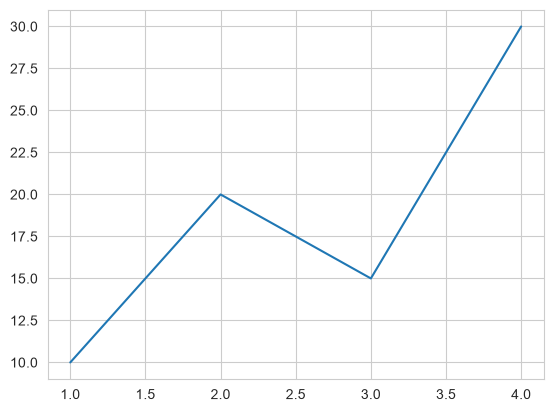

In [7]:
sns.set_style("whitegrid")

sns.lineplot(x=[1, 2, 3, 4], y=[10, 20, 15, 30])
plt.show()

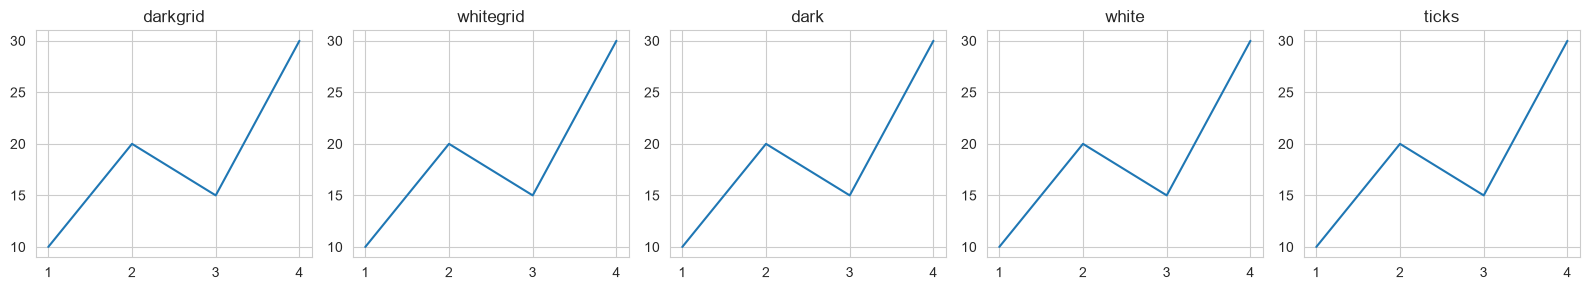

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, style in zip(axes, ["darkgrid", "whitegrid", "dark", "white", "ticks"]):
    sns.set_style(style)
    sns.lineplot(x=[1, 2, 3, 4], y=[10, 20, 15, 30], ax=ax)
    ax.set_title(style)
plt.tight_layout()
plt.show()
sns.set_style("whitegrid")   # back to our default

---
# 🌈 3. Color Palettes

Common palettes: `deep`, `muted`, `bright`, `pastel`, `dark`, `colorblind`. Color palettes are useful when comparing categories.

In [9]:
sns.color_palette()                      # the current palette

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [10]:
for name in ["deep", "muted", "bright", "pastel", "dark", "colorblind"]:
    print(name)
    display(sns.color_palette(name))     # renders colour swatches

deep


[(0.2980392156862745, 0.4470588235294118, 0.6901960784313725),
 (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
 (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
 (0.7686274509803922, 0.3058823529411765, 0.3215686274509804),
 (0.5058823529411764, 0.4470588235294118, 0.7019607843137254),
 (0.5764705882352941, 0.47058823529411764, 0.3764705882352941),
 (0.8549019607843137, 0.5450980392156862, 0.7647058823529411),
 (0.5490196078431373, 0.5490196078431373, 0.5490196078431373),
 (0.8, 0.7254901960784313, 0.4549019607843137),
 (0.39215686274509803, 0.7098039215686275, 0.803921568627451)]

muted


[(0.2823529411764706, 0.47058823529411764, 0.8156862745098039),
 (0.9333333333333333, 0.5215686274509804, 0.2901960784313726),
 (0.41568627450980394, 0.8, 0.39215686274509803),
 (0.8392156862745098, 0.37254901960784315, 0.37254901960784315),
 (0.5843137254901961, 0.4235294117647059, 0.7058823529411765),
 (0.5490196078431373, 0.3803921568627451, 0.23529411764705882),
 (0.8627450980392157, 0.49411764705882355, 0.7529411764705882),
 (0.4745098039215686, 0.4745098039215686, 0.4745098039215686),
 (0.8352941176470589, 0.7333333333333333, 0.403921568627451),
 (0.5098039215686274, 0.7764705882352941, 0.8862745098039215)]

bright


...

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

dark


[(0.0, 0.10980392156862745, 0.4980392156862745),
 (0.6941176470588235, 0.25098039215686274, 0.050980392156862744),
 (0.07058823529411765, 0.44313725490196076, 0.10980392156862745),
 (0.5490196078431373, 0.03137254901960784, 0.0),
 (0.34901960784313724, 0.11764705882352941, 0.44313725490196076),
 (0.34901960784313724, 0.1843137254901961, 0.050980392156862744),
 (0.6352941176470588, 0.20784313725490197, 0.5098039215686274),
 (0.23529411764705882, 0.23529411764705882, 0.23529411764705882),
 (0.7215686274509804, 0.5215686274509804, 0.0392156862745098),
 (0.0, 0.38823529411764707, 0.4549019607843137)]

colorblind


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [11]:
sns.set_palette("deep")

---
# 📈 4. Relational Plots

Relational plots help understand relationships between variables: `scatterplot()` and `lineplot()`.

## 🔵 Scatter Plot

Shows the relationship between two numerical variables. Useful for: *Does age relate to marks? Does experience relate to salary? Does advertising spending relate to sales?*

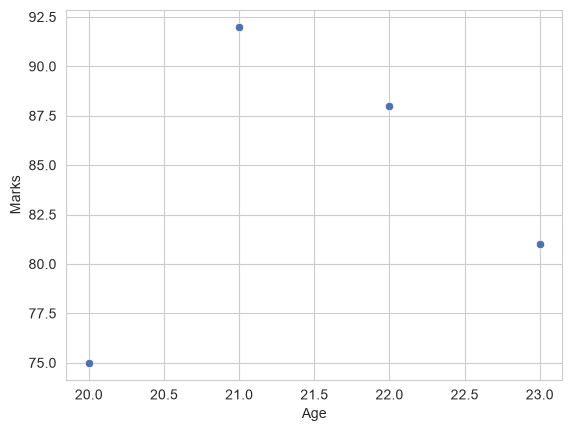

In [12]:
sns.scatterplot(data=df, x="Age", y="Marks")
plt.show()

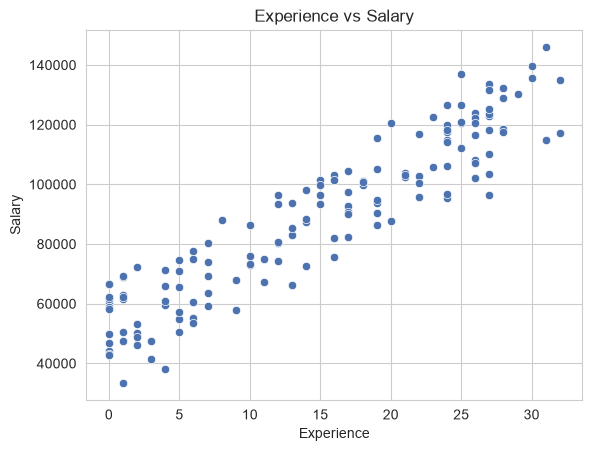

In [13]:
sns.scatterplot(data=big, x="Experience", y="Salary")
plt.title("Experience vs Salary")
plt.show()

## 📈 Line Plot

Useful for trends over time (Time → Sales / Temperature / Stock Price / Website Visitors).

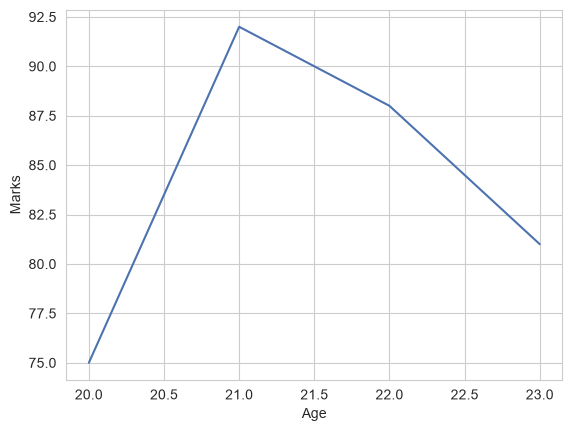

In [14]:
sns.lineplot(
    data=df,
    x="Age",
    y="Marks"
)

plt.show()

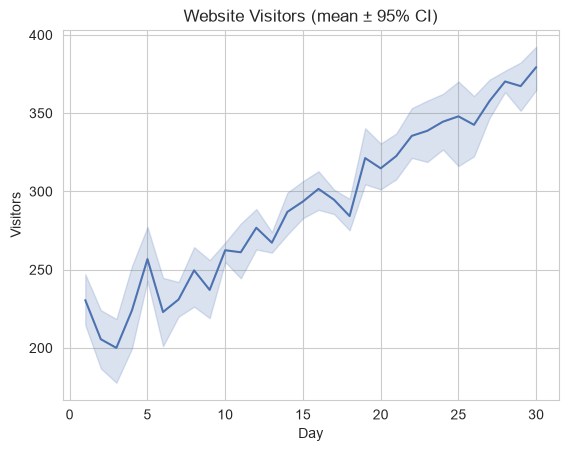

In [15]:
# A real time-series style line plot (with a confidence band from repeated measurements)
days = np.tile(np.arange(1, 31), 5)
visitors = 200 + days * 6 + np.random.default_rng(1).normal(0, 25, len(days))
traffic = pd.DataFrame({"Day": days, "Visitors": visitors})

sns.lineplot(data=traffic, x="Day", y="Visitors")
plt.title("Website Visitors (mean ± 95% CI)")
plt.show()

---
# 📊 5. Distribution Plots

Help understand how numerical data is distributed: `histplot()`, `kdeplot()`, `ecdfplot()`.

## 📊 Histogram

> How are values distributed?

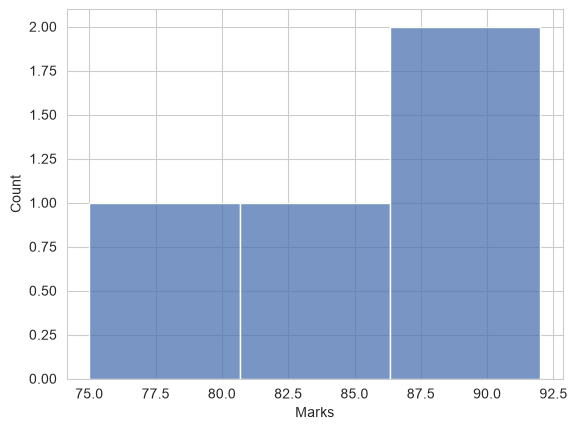

In [16]:
sns.histplot(data=df, x="Marks")

plt.show()

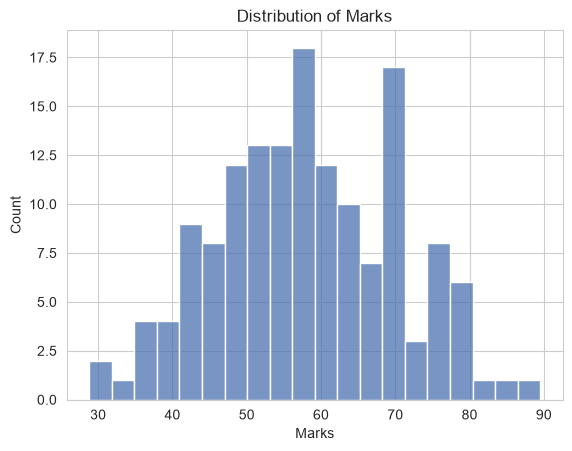

In [17]:
sns.histplot(data=big, x="Marks", bins=20)
plt.title("Distribution of Marks")
plt.show()

## 📈 KDE Plot

KDE = **Kernel Density Estimate** — an estimated smooth distribution curve; useful for understanding the shape of a distribution.

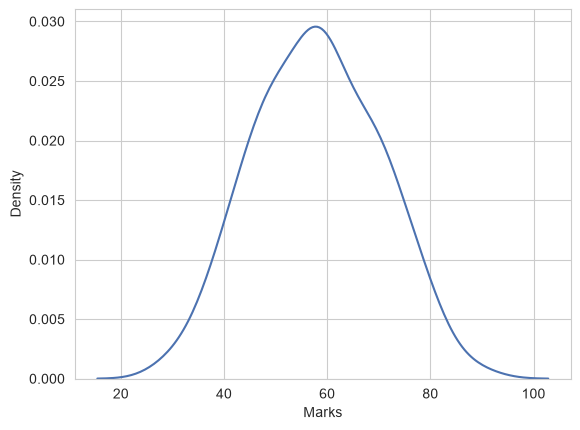

In [18]:
sns.kdeplot(data=big, x="Marks")

plt.show()

## 📊 Histogram + KDE

```text
Histogram → actual value distribution
KDE       → estimated smooth distribution
```

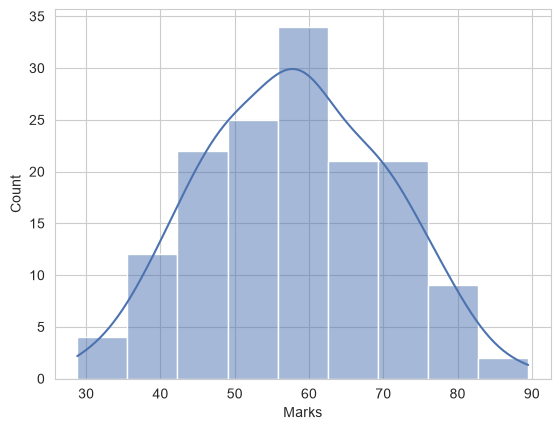

In [19]:
sns.histplot(
    data=big,
    x="Marks",
    kde=True
)

plt.show()

## 📉 ECDF Plot

Shows the proportion of observations ≤ each value (e.g. "what % of students scored below 60?").

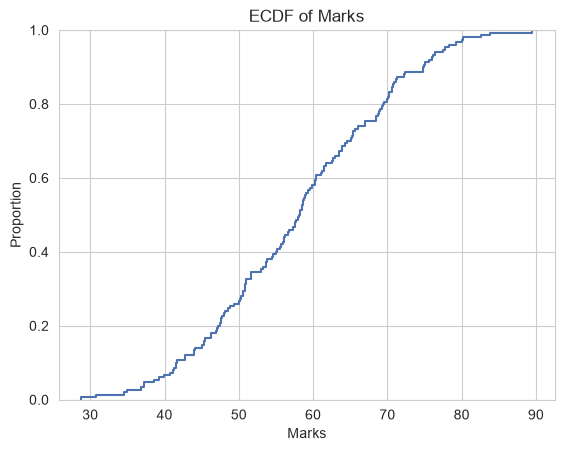

In [20]:
sns.ecdfplot(data=big, x="Marks")
plt.title("ECDF of Marks")
plt.show()

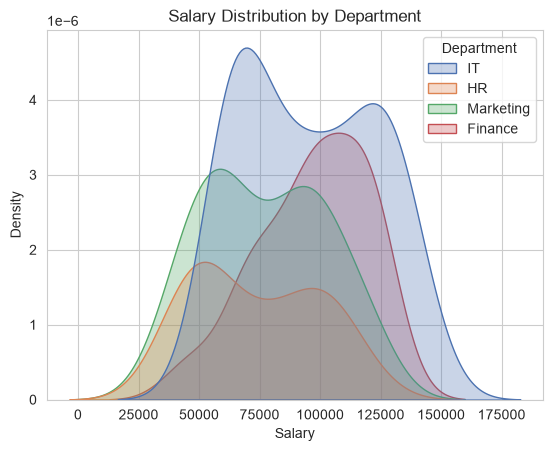

In [21]:
# Compare distributions with hue
sns.kdeplot(data=big, x="Salary", hue="Department", fill=True, alpha=0.3)
plt.title("Salary Distribution by Department")
plt.show()

---
# 🏷️ 6. Categorical Plots

Useful when your data contains categories such as Male/Female, Sales/Marketing/IT, Product A/B, Beginner/Intermediate/Advanced.

Functions: `barplot()`, `countplot()`, `boxplot()`, `violinplot()`, `stripplot()`, `swarmplot()`.

---
# 📊 7. Bar Plot

Compares a numerical value across categories (Department → Average Salary, Product → Average Sales…). By default Seaborn shows the **mean** with a confidence interval.

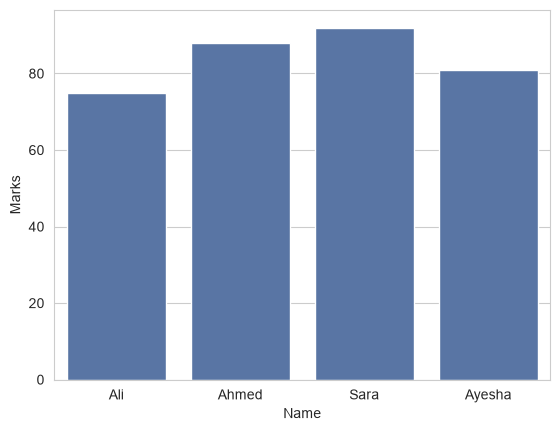

In [22]:
sns.barplot(
    data=df,
    x="Name",
    y="Marks"
)

plt.show()

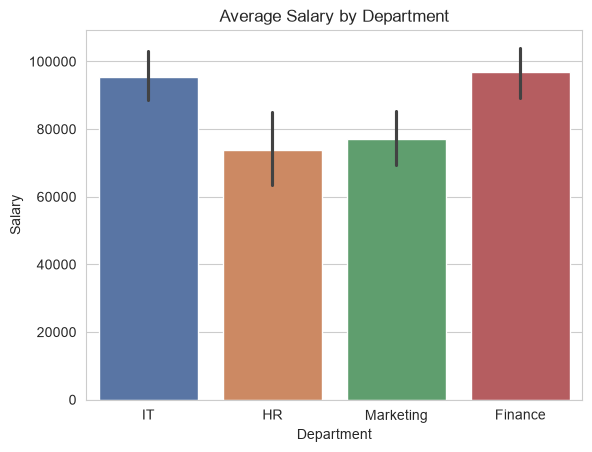

In [23]:
sns.barplot(data=big, x="Department", y="Salary", hue="Department", legend=False)
plt.title("Average Salary by Department")
plt.show()

---
# 🔢 8. Count Plot

Counts how many observations belong to each category.

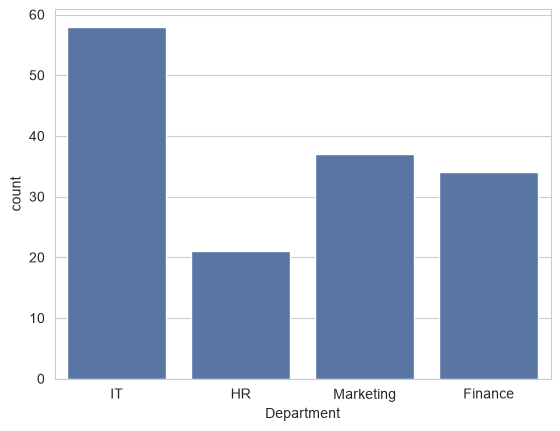

In [24]:
sns.countplot(
    data=big,
    x="Department"
)

plt.show()

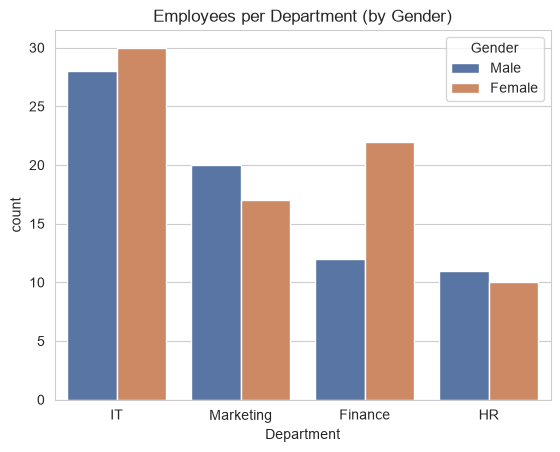

In [25]:
sns.countplot(data=big, x="Department", hue="Gender", order=big["Department"].value_counts().index)
plt.title("Employees per Department (by Gender)")
plt.show()

---
# 📦 9. Box Plot

Shows distribution and spread: median, quartiles, IQR, spread, potential outliers. Especially useful during **EDA**.

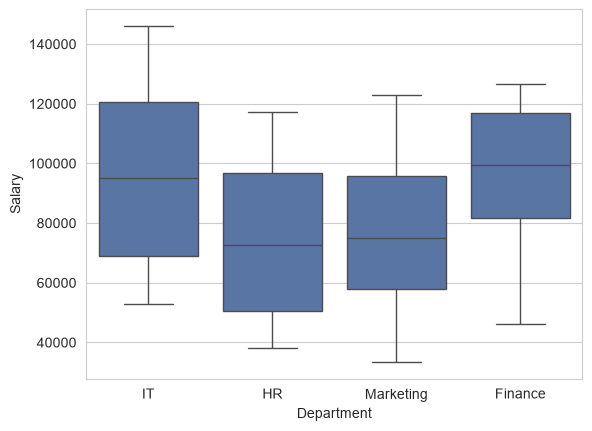

In [26]:
sns.boxplot(
    data=big,
    x="Department",
    y="Salary"
)

plt.show()

---
# 🎻 10. Violin Plot

Combines ideas from **Box Plot + KDE Distribution**; helps compare distributions across categories.

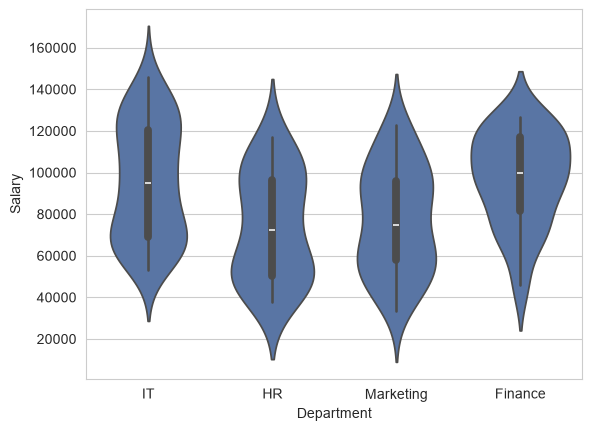

In [27]:
sns.violinplot(
    data=big,
    x="Department",
    y="Salary"
)

plt.show()

---
# 🟣 11. Strip Plot

Shows individual observations for each category.

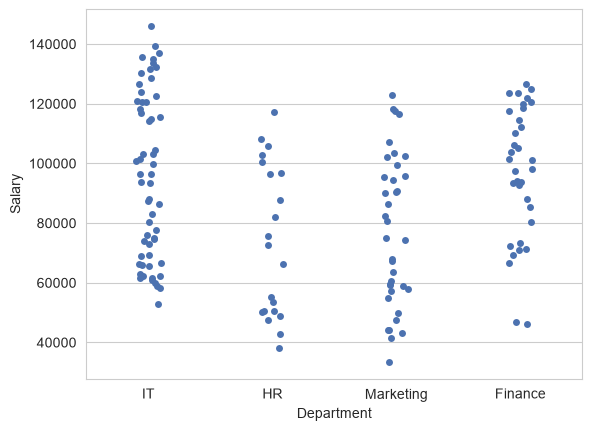

In [28]:
sns.stripplot(
    data=big,
    x="Department",
    y="Salary"
)

plt.show()

---
# 🐝 12. Swarm Plot

Shows individual observations while avoiding overlapping points. Best for smaller datasets.

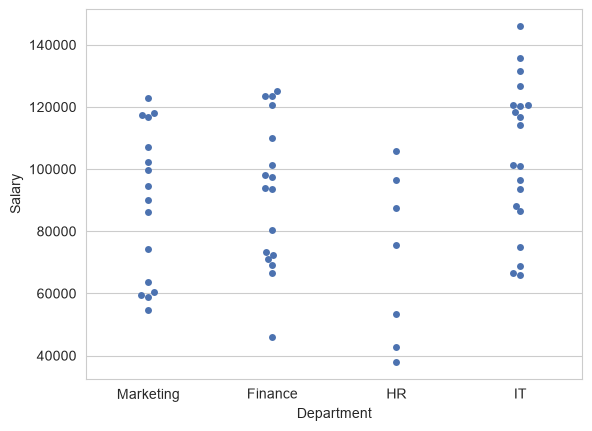

In [29]:
small = big.sample(60, random_state=1)

sns.swarmplot(
    data=small,
    x="Department",
    y="Salary"
)

plt.show()

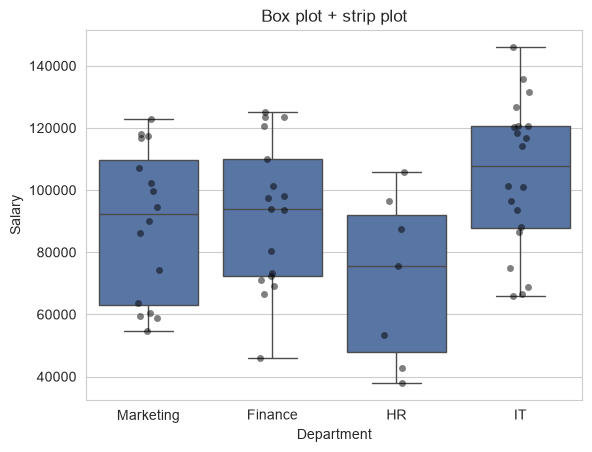

In [30]:
# Combine: box plot + individual points
sns.boxplot(data=small, x="Department", y="Salary", showfliers=False)
sns.stripplot(data=small, x="Department", y="Salary", color="black", alpha=0.5)
plt.title("Box plot + strip plot")
plt.show()

---
# 📈 13. Regression Plots

Visualize relationships together with a regression line.

## `regplot()`

Helps visually understand whether two variables have a linear relationship.

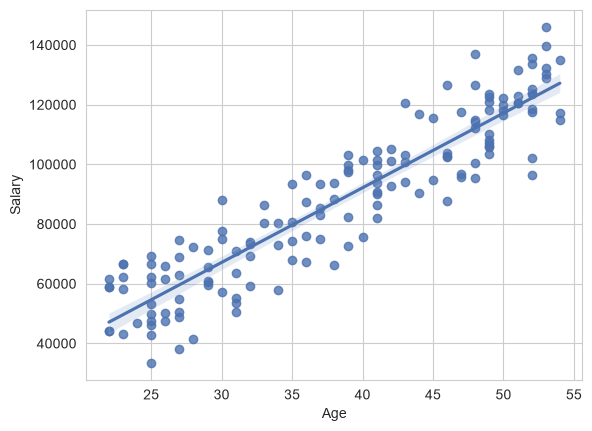

In [31]:
sns.regplot(
    data=big,
    x="Age",
    y="Salary"
)

plt.show()

## `lmplot()`

Figure-level version — supports `hue`, `col`, `row` for separate regressions per group.

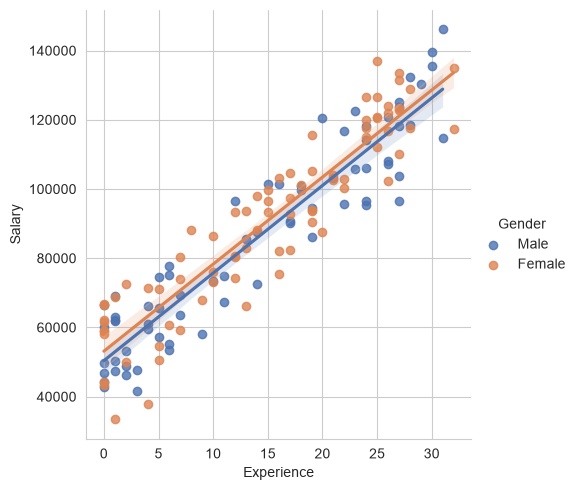

In [32]:
sns.lmplot(data=big, x="Experience", y="Salary", hue="Gender", height=5)
plt.show()

---
# 🔗 14. Pair Plot

`pairplot()` is extremely useful for EDA. It compares multiple numerical variables against each other (Age ↔ Salary, Age ↔ Experience, Salary ↔ Sales …) and shows distributions along the diagonal.

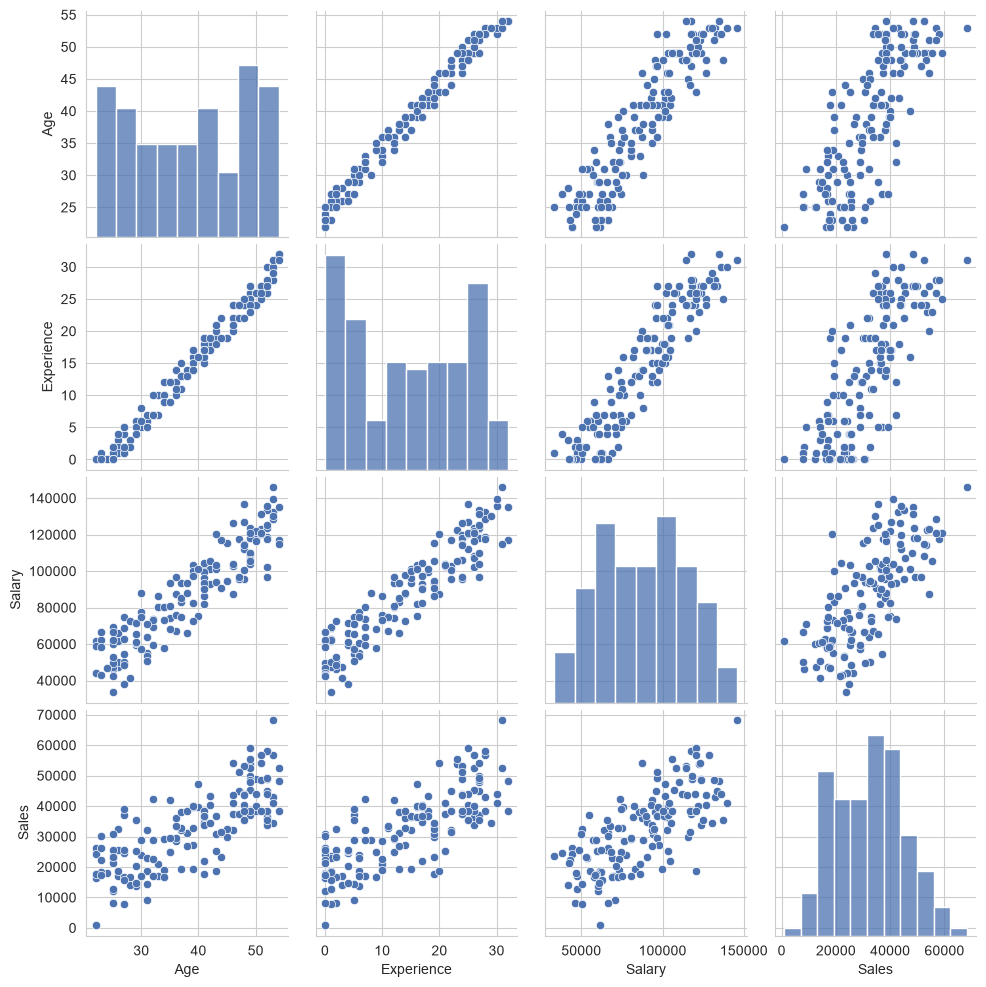

In [33]:
sns.pairplot(big[["Age", "Experience", "Salary", "Sales"]])

plt.show()

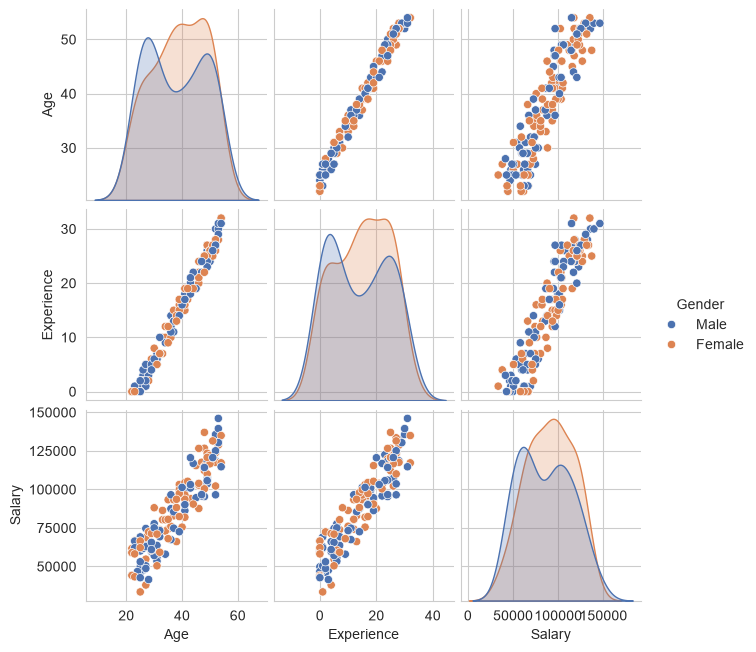

In [34]:
sns.pairplot(big[["Age", "Experience", "Salary", "Gender"]], hue="Gender", height=2.2)
plt.show()

---
# 🔍 15. Joint Plot

Shows the relationship between two variables along with their individual distributions.

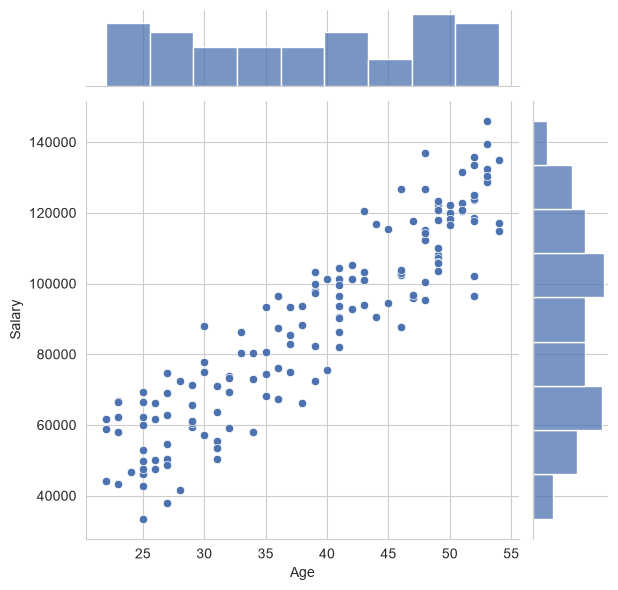

In [35]:
sns.jointplot(
    data=big,
    x="Age",
    y="Salary"
)

plt.show()

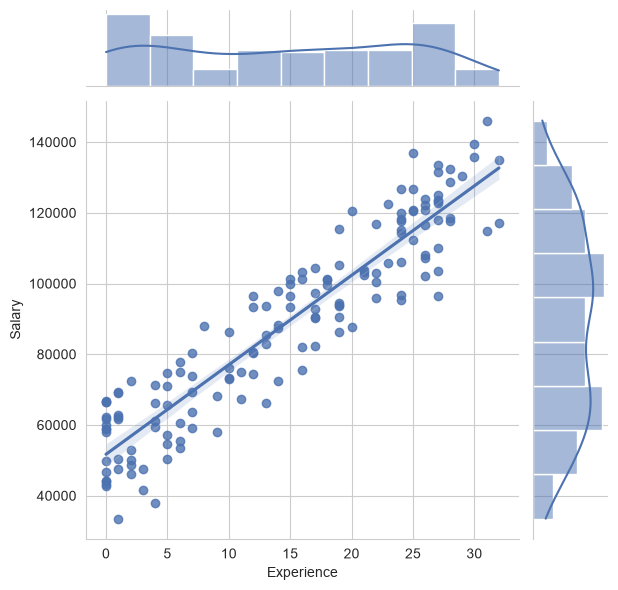

In [36]:
sns.jointplot(data=big, x="Experience", y="Salary", kind="reg")
plt.show()

---
# 🔥 16. Heatmap

A heatmap represents values using colors. One of its most important Data Science uses is **correlation visualization**.

```text
             Age   Salary
Age          1.00   0.75
Salary       0.75   1.00
```

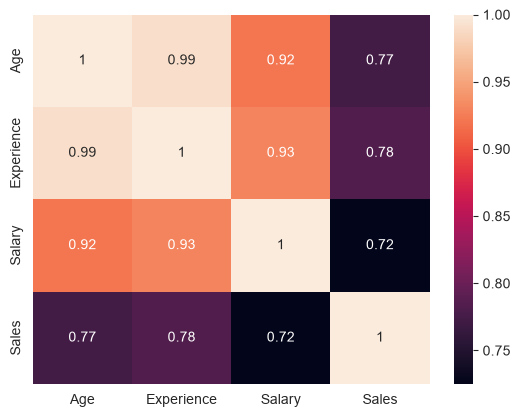

In [37]:
correlation = big[["Age", "Experience", "Salary", "Sales"]].corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True
)

plt.show()

---
# 🧠 17. Correlation Heatmap

Very commonly used during EDA. It helps identify **positive**, **negative**, **weak** and **strong** correlation.

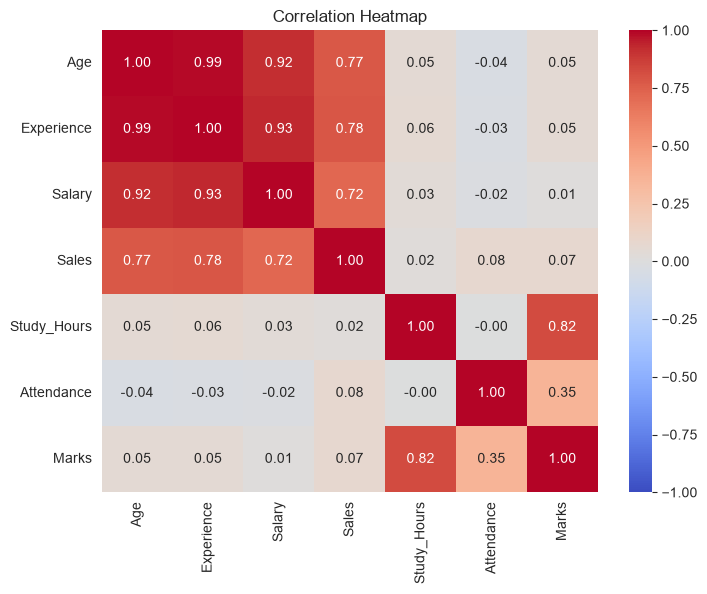

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    big.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1, vmax=1
)
plt.title("Correlation Heatmap")
plt.show()

> ⚠️ Correlation ≠ causation. A strong correlation only tells you two variables move together.

### `clustermap()` — heatmap with similar rows/columns grouped together

In [39]:
sns.clustermap(big.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", figsize=(7, 7))
plt.show()

RuntimeError: clustermap requires scipy to be available

---
# 🧩 18. FacetGrid

`FacetGrid` allows you to create multiple plots based on categories, so groups can be compared separately.

In [ ]:
g = sns.FacetGrid(
    big,
    col="Gender"
)

g.map_dataframe(
    sns.scatterplot,
    x="Age",
    y="Salary"
)

plt.show()

In [ ]:
g = sns.FacetGrid(big, col="Department", col_wrap=2, height=3)
g.map_dataframe(sns.histplot, x="Salary", bins=10)
g.set_titles("{col_name}")
plt.show()

---
# 🎛️ 19. Important Seaborn Parameters

| Parameter | Purpose                 |
| --------- | ----------------------- |
| `data`    | DataFrame/dataset       |
| `x`       | X-axis variable         |
| `y`       | Y-axis variable         |
| `hue`     | Color/group by category |
| `style`   | Different marker styles |
| `size`    | Change point size       |
| `palette` | Color palette           |
| `bins`    | Histogram groups        |
| `order`   | Category order          |
| `col`     | Create separate columns |
| `row`     | Create separate rows    |
| `orient`  | Plot orientation        |

---
# 🎨 20. Using `hue`

`hue` is one of Seaborn's most useful features. Instead of manually creating separate plots, Seaborn automatically distinguishes categories.

In [ ]:
sns.scatterplot(
    data=big,
    x="Age",
    y="Salary",
    hue="Gender"
)

plt.show()

In [ ]:
# hue + style + size + palette together
sns.scatterplot(
    data=big, x="Experience", y="Salary",
    hue="Department", style="Gender", size="Sales",
    palette="colorblind", sizes=(20, 200), alpha=0.8
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [ ]:
# orient="h" for horizontal category plots
sns.boxplot(data=big, y="Department", x="Salary", orient="h", hue="Department", legend=False, palette="pastel")
plt.show()

---
# 📏 21. Figure Size

Seaborn works with Matplotlib for figure customization.

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=big,
    x="Age",
    y="Salary"
)

plt.show()

---
# 🏷️ 22. Titles and Labels

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=big,
    x="Department",
    y="Salary"
)

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()

---
# 🧱 23. Seaborn + Matplotlib

They are not competitors. They work together.

In [ ]:
sns.scatterplot(
    data=big,
    x="Age",
    y="Salary"
)

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.grid(True)

plt.show()

### Figure and Axes — drawing Seaborn plots on Matplotlib subplots (`ax=`)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=big, x="Salary", kde=True, ax=axes[0])
sns.boxplot(data=big, x="Department", y="Salary", ax=axes[1])
sns.scatterplot(data=big, x="Experience", y="Salary", hue="Gender", ax=axes[2])

axes[0].set_title("Histogram")
axes[1].set_title("Box plot")
axes[2].set_title("Scatter")
plt.tight_layout()
plt.show()

| Library    | Main Purpose              |
| ---------- | ------------------------- |
| NumPy      | Numerical computation     |
| Pandas     | Data manipulation         |
| Matplotlib | Flexible visualization    |
| Seaborn    | Statistical visualization |

---
# 🐼 24. Seaborn + Pandas

A typical Data Science workflow — read a CSV and plot straight from the DataFrame. (We first save our dataset to `students.csv` so the example runs.)

In [ ]:
big.to_csv("students.csv", index=False)

df2 = pd.read_csv("students.csv")

sns.boxplot(
    data=df2,
    x="Gender",
    y="Marks"
)

plt.show()

---
# 🔎 25. Seaborn for EDA

```text
Load Dataset → Inspect Data → Clean Data → Understand Variables → Visualize Distributions
→ Analyze Relationships → Find Outliers → Analyze Correlations → Extract Insights
```

| Question                                  | Plot         |
| ----------------------------------------- | ------------ |
| What is the distribution?                 | Histogram    |
| How are two variables related?            | Scatter Plot |
| What is the trend?                        | Line Plot    |
| How do categories compare?                | Bar Plot     |
| How many observations per category?       | Count Plot   |
| Are there outliers?                       | Box Plot     |
| How does distribution differ by category? | Violin Plot  |
| How do many variables relate?             | Pair Plot    |
| How are variables correlated?             | Heatmap      |

A compact EDA in one go:

In [ ]:
# 1) Inspect
print(big.shape)
print(big.isna().sum().sum(), "missing values")
display(big.describe().round(1))

In [ ]:
# 2) Distributions of every numeric column
num_cols = ["Age", "Experience", "Salary", "Sales", "Study_Hours", "Attendance", "Marks"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(big[col], kde=True, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# 3) Outliers  4) Correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=big[["Salary", "Sales"]], ax=axes[0])
axes[0].set_title("Outlier check")
sns.heatmap(big[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlations")
plt.tight_layout()
plt.show()

---
# 🏢 26. Real-World Applications

* 🛒 **E-Commerce** — Product → Sales, Category → Revenue, Price → Quantity, Customer Age → Spending
* 💰 **Finance** — stock price, returns, risk, correlation, portfolio data
* 🏥 **Healthcare** — Age → Disease rate, BMI → Health outcomes, Treatment → Recovery
* 🎓 **Education** — Study Hours → Marks, Attendance → Performance, Gender → Scores
* 🏢 **Business** — Department → Salary, Experience → Salary, Salesperson → Revenue, Region → Sales

---
# 🤖 27. Seaborn in Machine Learning

```text
Dataset → Pandas → EDA → Seaborn → Understand relationships → Feature selection → Machine Learning
```

Seaborn can help identify important relationships, outliers, data distributions, correlations, possible feature relationships and class distributions.

In [ ]:
# Example: class distribution + feature relationships for a classification problem
ml = big.copy()
ml["High_Earner"] = np.where(ml["Salary"] > ml["Salary"].median(), "Yes", "No")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=ml, x="High_Earner", ax=axes[0])
axes[0].set_title("Class distribution (check for imbalance)")
sns.scatterplot(data=ml, x="Experience", y="Age", hue="High_Earner", ax=axes[1])
axes[1].set_title("Feature relationship by class")
plt.tight_layout()
plt.show()

---
# 🧠 28. Important Seaborn Functions

| Function            | Purpose                          |
| ------------------- | -------------------------------- |
| `sns.scatterplot()` | Relationship between variables   |
| `sns.lineplot()`    | Trends                           |
| `sns.histplot()`    | Distribution                     |
| `sns.kdeplot()`     | Density distribution             |
| `sns.barplot()`     | Category comparison              |
| `sns.countplot()`   | Category counts                  |
| `sns.boxplot()`     | Distribution + outliers          |
| `sns.violinplot()`  | Distribution comparison          |
| `sns.stripplot()`   | Individual observations          |
| `sns.swarmplot()`   | Non-overlapping observations     |
| `sns.regplot()`     | Regression relationship          |
| `sns.pairplot()`    | Multiple variable relationships  |
| `sns.jointplot()`   | Two-variable relationship        |
| `sns.heatmap()`     | Matrix/correlation visualization |
| `sns.FacetGrid()`   | Multiple grouped plots           |

---
# 🆚 Matplotlib vs Seaborn

| Feature              | Matplotlib            | Seaborn                 |
| -------------------- | --------------------- | ----------------------- |
| Flexibility          | Very high             | High                    |
| Statistical plots    | More manual           | Easier                  |
| Default appearance   | Basic                 | More polished           |
| DataFrame support    | Good                  | Excellent               |
| EDA                  | Good                  | Excellent               |
| Fine-grained control | Excellent             | Good                    |
| Learning curve       | Moderate              | Easier for common plots |
| Built on             | Core plotting library | Matplotlib              |

### Important

Don't think *"Seaborn replaces Matplotlib."* Instead:

> **Seaborn makes statistical visualization easier, while Matplotlib provides deeper control.**

---
# 🧪 Practice Exercises

Write your solution in the code cell under each exercise.

### Exercise 1 — Scatter Plot

Create a dataset containing `Age` and `Salary`. Create a scatter plot showing their relationship.

In [ ]:
# Write your solution here

### Exercise 2 — Histogram

Create a histogram for `Student Marks`. Analyze the distribution.

In [ ]:
# Write your solution here

### Exercise 3 — Count Plot

Create a dataset containing `Department`. Show how many employees belong to each department.

In [ ]:
# Write your solution here

### Exercise 4 — Box Plot

Create `Department` and `Salary`. Use a box plot to compare salary distributions.

In [ ]:
# Write your solution here

### Exercise 5 — Heatmap

Create a dataset containing `Age, Experience, Salary, Sales`. Create a correlation matrix and visualize it using a heatmap.

In [ ]:
# Write your solution here

### Exercise 6 — Pair Plot

Use a dataset containing several numerical columns and create `sns.pairplot(df)`. Try to identify relationships between variables.

In [ ]:
# Write your solution here

---
# 🚀 Mini Project — Student Performance Visualization

Dataset columns: `Name, Gender, Age, Study_Hours, Attendance, Marks` (we reuse the generated `big` DataFrame, which already has them).

**Questions to answer:**

1. What is the distribution of marks?
2. Is study time related to marks?
3. Does attendance relate to marks?
4. How do marks differ by gender?
5. Are there unusual/outlier marks?
6. Which variables have strong correlations?

```text
Student Dataset → Pandas → Clean Data → Seaborn → Visualizations → Find Patterns → Write Insights
```

In [ ]:
students = big[["Name", "Gender", "Age", "Study_Hours", "Attendance", "Marks"]].copy()
print(students.isna().sum().sum(), "missing |", students.duplicated().sum(), "duplicates")   # clean check
students.head()

### 1. Histogram

In [ ]:
sns.histplot(data=students, x="Marks", kde=True, bins=15)
plt.title("Distribution of Marks"); plt.show()

### 2. Scatter Plot

In [ ]:
sns.scatterplot(data=students, x="Study_Hours", y="Marks", hue="Gender")
plt.title("Study Hours vs Marks"); plt.show()

### 3. Line Plot

In [ ]:
students["Hours_Rounded"] = students["Study_Hours"].round()
sns.lineplot(data=students, x="Hours_Rounded", y="Marks", marker="o")
plt.title("Average Marks by Study Hours (rounded)"); plt.show()

### 4. Bar Plot

In [ ]:
sns.barplot(data=students, x="Gender", y="Marks", hue="Gender", legend=False)
plt.title("Average Marks by Gender"); plt.show()

### 5. Count Plot

In [ ]:
students["Attendance_Level"] = pd.cut(students["Attendance"], [0, 75, 90, 100], labels=["Low", "Medium", "High"])
sns.countplot(data=students, x="Attendance_Level")
plt.title("Students per Attendance Level"); plt.show()

### 6. Box Plot

In [ ]:
sns.boxplot(data=students, x="Attendance_Level", y="Marks")
plt.title("Marks by Attendance Level"); plt.show()

### 7. Violin Plot

In [ ]:
sns.violinplot(data=students, x="Gender", y="Marks", hue="Gender", legend=False)
plt.title("Marks Distribution by Gender"); plt.show()

### 8. Pair Plot

In [ ]:
sns.pairplot(students[["Age", "Study_Hours", "Attendance", "Marks"]])
plt.show()

### 9. Correlation Heatmap

In [ ]:
sns.heatmap(students[["Age", "Study_Hours", "Attendance", "Marks"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap"); plt.show()

### ✍️ Write Insights

Double-click this cell and write your findings (e.g. *"Study hours shows the strongest positive correlation with marks; attendance has a weaker positive relationship; no major gender difference; …"*). Remember: correlation does not prove causation.

---
# 🎯 Learning Goals

After completing **Class 20 — Seaborn**, you should understand:

- [ ] What Seaborn is and why it is used
- [ ] Seaborn vs Matplotlib
- [ ] How Seaborn works with Pandas
- [ ] Seaborn themes and styles
- [ ] Color palettes
- [ ] Scatter plots, line plots
- [ ] Histograms, KDE plots
- [ ] Bar plots, count plots
- [ ] Box plots, violin plots, strip plots, swarm plots
- [ ] Regression plots
- [ ] Pair plots, joint plots
- [ ] Heatmaps
- [ ] FacetGrid
- [ ] `hue`, `style`, and `size`
- [ ] EDA visualization
- [ ] Seaborn + Matplotlib
- [ ] Seaborn + Pandas
- [ ] Visualization selection
- [ ] Data Science visualization workflow

---
# ❓ Interview Questions

### Beginner
1. What is Seaborn?
2. Why is Seaborn used in Data Science?
3. How is Seaborn related to Matplotlib?
4. How do you import Seaborn?
5. What is `sns.scatterplot()`?
6. What is `sns.histplot()`?
7. What is `sns.barplot()`?
8. What is `sns.countplot()`?

### Intermediate
9. What is the difference between `barplot()` and `countplot()`?
10. What is the difference between a histogram and KDE plot?
11. What is a box plot?
12. How can a box plot help identify outliers?
13. What is `hue` in Seaborn?
14. What is `pairplot()`?
15. What is a heatmap?
16. How do you visualize correlations?
17. How does Seaborn work with Pandas?
18. How can Matplotlib be used with Seaborn?

### Practical
19. Which plot would you use to show the relationship between two numerical variables?
20. Which plot would you use to compare categories?
21. Which plot would you use to identify outliers?
22. Which plot would you use to visualize correlations?
23. Which plot would you use to understand a numerical distribution?
24. How would you visualize an EDA dataset?

---
# 🧠 Visualization Decision Guide

```text
Relationship?            → Scatter Plot
Trend?                   → Line Plot
Distribution?            → Histogram / KDE
Category comparison?     → Bar Plot
Category frequency?      → Count Plot
Outliers?                → Box Plot
Distribution + categories? → Violin Plot
Many relationships?      → Pair Plot
Correlation?             → Heatmap
```

---
# 🔗 Data Science Library Connection

```text
              Data Science
                   │
        ┌──────────┴──────────┐
      NumPy                 Pandas
   Numerical Data        Data Analysis
        └──────────┬──────────┘
               Matplotlib  → General Visualization
                   ↓
                Seaborn    → Statistical Visualization
                   ↓
                  EDA → Machine Learning
```

---
# 📁 Folder Structure

```text
02-Data-Science/
├── README.md
├── 01-NumPy/       (README.md, class17.ipynb)
├── 02-Pandas/      (README.md, class18.ipynb)
├── 03-Matplotlib/  (README.md, class19.ipynb)
└── 04-Seaborn/     (README.md, class20.ipynb)
```

---
# 🧠 Key Takeaways

> **Seaborn = Statistical Data Visualization made easier.**

```text
NumPy      → Numerical computation
Pandas     → Data manipulation and analysis
Matplotlib → General-purpose visualization
Seaborn    → Statistical visualization + EDA
```

The most important Seaborn skills: `scatterplot()`, `lineplot()`, `histplot()`, `barplot()`, `countplot()`, `boxplot()`, `violinplot()`, `pairplot()`, `heatmap()`.

And the most important EDA idea is:

> **Don't just create charts — use charts to understand the data and find meaningful patterns.**

---
# 🗺️ Data Science Roadmap

```text
01. NumPy → 02. Pandas → 03. Matplotlib → 04. Seaborn → 05. Data Cleaning → 06. Exploratory Data Analysis → 07. Statistics → 08. Machine Learning
```

## 🎯 Final Goal

By completing **NumPy → Pandas → Matplotlib → Seaborn**, you will have the core Python tools needed to work with, analyze, and visualize real-world datasets.

**Next:** `05-Data-Cleaning/` 🧹